In [1]:
import supervision as sv
from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print(f"Supervision versión: {sv.__version__}")

Supervision versión: 0.28.0


Imagen cargada: (581, 387, 3)


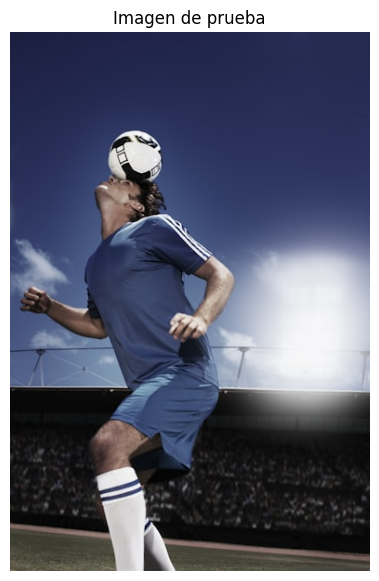

In [2]:
import urllib.request

Path("assets/fotos").mkdir(exist_ok=True)

urllib.request.urlretrieve(
    "https://plus.unsplash.com/premium_photo-1664297521832-0ea5ea948a67?q=80&w=387&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",
    "assets/fotos/pelota.jpg"
)

image = cv2.imread("assets/fotos/pelota.jpg")
print(f"Imagen cargada: {image.shape}")
# image.shape → (alto, ancho, canales)
# Los canales son BGR en OpenCV (azul, verde, rojo) — no RGB como en matplotlib

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Imagen de prueba")
plt.show()

In [3]:
model = YOLO("yolov8s.pt")
# nano, small, large...

In [4]:
results = model(image)[0]
# [0] toma el primer (y único) resultado — siempre necesario aunque proceses una sola imagen

detections = sv.Detections.from_ultralytics(results)
# Estandariza el output de YOLO


0: 640x448 1 person, 1 sports ball, 780.1ms
Speed: 24.5ms preprocess, 780.1ms inference, 22.4ms postprocess per image at shape (1, 3, 640, 448)


In [5]:
print(f"Número de objetos detectados: {len(detections)}")

print(f"\n--- xyxy: coordenadas del bounding box ---")
print("Formato: [x_izquierda, y_arriba, x_derecha, y_abajo]")
print(detections.xyxy)

print(f"\n--- confidence: certeza del modelo (0 = inseguro, 1 = muy seguro) ---")
print(detections.confidence)

print(f"\n--- class_id: número de la categoría detectada ---")
print(detections.class_id)

print(f"\n--- Traducción de class_id a nombre ---")
for class_id in sorted(set(detections.class_id)):
    print(f"  Clase {class_id}: {results.names[class_id]}")

Número de objetos detectados: 2

--- xyxy: coordenadas del bounding box ---
Formato: [x_izquierda, y_arriba, x_derecha, y_abajo]
[[     104.85      106.12      164.04      163.48]
 [     9.7905      106.66      241.66         581]]

--- confidence: certeza del modelo (0 = inseguro, 1 = muy seguro) ---
[    0.93199     0.92183]

--- class_id: número de la categoría detectada ---
[32  0]

--- Traducción de class_id a nombre ---
  Clase 0: person
  Clase 32: sports ball


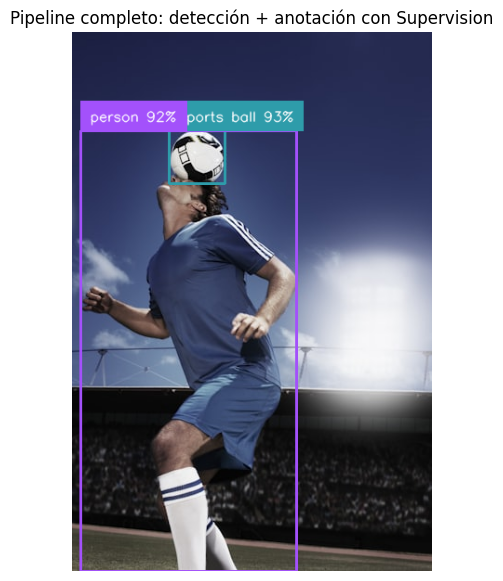

In [6]:
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

labels = [
    f"{results.names[class_id]} {conf:.0%}"
    for class_id, conf in zip(detections.class_id, detections.confidence)
]

# image.copy() es IMPORTANTE: evita modificar la imagen original
annotated = box_annotator.annotate(scene=image.copy(), detections=detections)
annotated = label_annotator.annotate(scene=annotated, detections=detections, labels=labels)

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Pipeline completo: detección + anotación con Supervision")
plt.show()

In [7]:
results_estricto = model(image, conf=0.8)[0]
detections_estricto = sv.Detections.from_ultralytics(results_estricto)

print(f"Con conf=0.5 (por defecto): {len(detections)} objetos detectados")
print(f"Con conf=0.8 (estricto):    {len(detections_estricto)} objetos detectados")

# Modelo más estricto = Menos objetos detectados


0: 640x448 1 person, 1 sports ball, 816.2ms
Speed: 31.1ms preprocess, 816.2ms inference, 2.7ms postprocess per image at shape (1, 3, 640, 448)
Con conf=0.5 (por defecto): 2 objetos detectados
Con conf=0.8 (estricto):    2 objetos detectados


In [8]:
primera = detections[0]

x1, y1, x2, y2 = primera.xyxy[0]
print(f"Primera detección:")
print(f"  Clase:    {results.names[primera.class_id[0]]}")
print(f"  Confianza: {primera.confidence[0]:.1%}")
print(f"  Posición:  esquina superior-izquierda ({x1:.0f}, {y1:.0f})")
print(f"             esquina inferior-derecha   ({x2:.0f}, {y2:.0f})")
print(f"  Tamaño:    {x2-x1:.0f} px de ancho × {y2-y1:.0f} px de alto")

# Primera detección del modelo: Vaca 

Primera detección:
  Clase:    sports ball
  Confianza: 93.2%
  Posición:  esquina superior-izquierda (105, 106)
             esquina inferior-derecha   (164, 163)
  Tamaño:    59 px de ancho × 57 px de alto


In [9]:
model_s = YOLO("yolov8s.pt") 
results_s = model_s(image)[0]
detections_s = sv.Detections.from_ultralytics(results_s)

print(f"yolov8n (nano):  {len(detections)} objetos")
print(f"yolov8s (small): {len(detections_s)} objetos")

# Pueden detectar los mismos objetos, más la confianza variará


0: 640x448 1 person, 1 sports ball, 381.7ms
Speed: 2.4ms preprocess, 381.7ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 448)
yolov8n (nano):  2 objetos
yolov8s (small): 2 objetos


In [10]:
import json

def detections_to_dict(detections, class_names=None):
    """Convierte sv.Detections a un dict JSON-compatible."""
    return {
        "xyxy":        detections.xyxy.tolist(),
        "confidence":  detections.confidence.tolist() if detections.confidence is not None else None,
        "class_id":    detections.class_id.tolist()   if detections.class_id   is not None else None,
        "class_names": [class_names[c] for c in detections.class_id]
                       if (class_names and detections.class_id is not None) else None,
    }

resultado = detections_to_dict(detections, class_names=results.names)

with open("assets/predicciones/predicciones.json", "w", encoding="utf-8") as f:
    json.dump(resultado, f, indent=2, ensure_ascii=False)

print("Guardado: assets/predicciones/predicciones.json")
print(json.dumps(resultado, indent=2))

Guardado: assets/predicciones/predicciones.json
{
  "xyxy": [
    [
      104.84979248046875,
      106.11897277832031,
      164.04190063476562,
      163.4787139892578
    ],
    [
      9.790533065795898,
      106.65910339355469,
      241.65939331054688,
      581.0
    ]
  ],
  "confidence": [
    0.9319931268692017,
    0.9218339920043945
  ],
  "class_id": [
    32,
    0
  ],
  "class_names": [
    "sports ball",
    "person"
  ]
}


In [11]:
import json

def detections_to_dict(detections, class_names=None):
    """Convierte sv.Detections a un dict JSON-compatible."""
    return {
        "xyxy":        detections.xyxy.tolist(),
        "confidence":  detections.confidence.tolist() if detections.confidence is not None else None,
        "class_id":    detections.class_id.tolist()   if detections.class_id   is not None else None,
        "class_names": [class_names[c] for c in detections.class_id]
                       if (class_names and detections.class_id is not None) else None,
    }

resultado = detections_to_dict(detections, class_names=results.names)

with open("assets/predicciones/predicciones.json", "w", encoding="utf-8") as f:
    json.dump(resultado, f, indent=2, ensure_ascii=False)

print("Guardado: assets/predicciones/predicciones.json")
print(json.dumps(resultado, indent=2))

Guardado: assets/predicciones/predicciones.json
{
  "xyxy": [
    [
      104.84979248046875,
      106.11897277832031,
      164.04190063476562,
      163.4787139892578
    ],
    [
      9.790533065795898,
      106.65910339355469,
      241.65939331054688,
      581.0
    ]
  ],
  "confidence": [
    0.9319931268692017,
    0.9218339920043945
  ],
  "class_id": [
    32,
    0
  ],
  "class_names": [
    "sports ball",
    "person"
  ]
}
